In [ ]:
from langchain_core.caches import InMemoryCache

from agents import *
from langchain_ollama import ChatOllama

In [4]:
############################################################################################################################################################
# QWEN3.5
############################################################################################################################################################
from sklearn.metrics import classification_report
from agents import *
import pandas as pd
import json
from tools import *
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('data/example/example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
for acc in accessions:
    result = MESOTHERMOPSYCHRO(acc, "qwen3.5")
    print(f'Accession: {acc}\nThermal Range: {result["thermal_range"]}\n\n')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)

all_df.to_csv('results/qwen3.5/result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']
plot=ConfusionMatrix(actual, pred)
plot.plot(cmap='Blues')
plt.savefig('results/qwen3.5/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('results/qwen3.5/result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual, pred)

with open('results/qwen3.5/classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')



ClassifyThermalMetadata: thermal_range='None' temperature=None inference_type='none' thermal_reasoning="The metadata provides the host ('Enterobacteriales') and a specific sampling location ('China: Donghu Lake, Wuhan'). While 'Donghu Lake' is a freshwater body, the metadata does not explicitly state the water temperature, depth, or specific environmental conditions (e.g., 'deep', 'polar', 'hot spring') that would allow for an inference of a thermal range according to the provided rules. Without explicit temperature data or descriptors implying extreme environments (Arctic, hot spring), no thermal classification can be derived." thermal_confidence=None thermal_found=False


download: s3://pmc-oa-opendata/PMC13048485.1/PMC13048485.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13048485.1.txt
download: s3://pmc-oa-opendata/PMC13030558.1/PMC13030558.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13030558.1.txt
download: s3://pmc-oa-opendata/PMC13055312.1/PMC1305531

OutputParserException: Failed to parse ThermalOutput from completion {"thermal_range": "mesophile", "temperature": "up to 60°C", "thermal_reasoning": "The paper explicitly states in the Abstract that phage P19 'remained highly stable across pH 6–10 and temperatures up to 60°C'. Section 3.6 ('pH And Thermal Stability') further details that 'phage P19 retained viability at temperatures ranging from 30°C to 60°C'. The organism in question is Tequatrovirus T4, which is mentioned in the Abstract as the type of lysozyme encoded by ORF_358 ('ORF_358 encodes a stable and soluble T4‐type lysozyme endolysin'). However, the thermal stability data provided (up to 60°C) refers to the specific phage P19 isolated in this study, not the generic Tequatrovirus T4. Since the prompt asks for the thermal characteristics of 'Tequatrovirus T4' but the paper only provides data for 'phage P19' (which contains a T4-type lysozyme), and strictly forbids inferring thermal range from species name or prior knowledge

ClassifyThermalMetadata: thermal_range='mesophile' temperature=None inference_type='inferred' thermal_reasoning="The metadata indicates the isolation source is 'China: Donghu Lake, Wuhan'. Lakes are generally associated with mesophilic environments, leading to the inference of a mesophilic thermal range based on the provided mapping rules." thermal_confidence=None thermal_found=True


Accession: ADI87650
Thermal Range: mesophile


ClassifyThermalMetadata: thermal_range='None' temperature=None inference_type='none' thermal_reasoning="The metadata provides the isolation source ('USA') and collection date, but no explicit or strongly implied environmental context (like 'hot spring', 'ice', or 'deep sea') that maps to a specific thermal range (psychrophile, mesophile, or thermophile)." thermal_confidence=None thermal_found=False


download: s3://pmc-oa-opendata/PMC10933291.1/PMC10933291.1.txt to data/accessions/WXH46553/library/accession_lit/PMC10933291.1.txt
ClassifyThermalLiterature: the

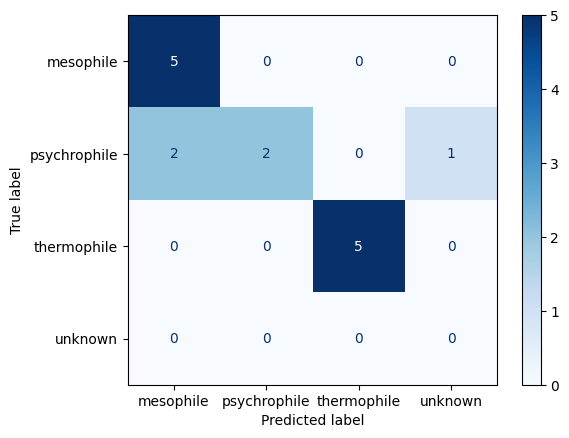

Total Duration: 7.41 minutes


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [3]:
############################################################################################################################################################
# GEMMA4
############################################################################################################################################################
from sklearn.metrics import classification_report
from agents import *
import pandas as pd
import json
from tools import *
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('data/example/example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
for acc in accessions:
    result = MESOTHERMOPSYCHRO(acc, "gemma4:e4b")
    print(f'Accession: {acc}\nThermal Range: {result["thermal_range"]}\n\n')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)

all_df.to_csv('results/gemma4/result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('results/gemma4/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('results/gemma4/result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('results/gemma4/classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


ClassifyThermalMetadata: thermal_range='mesophile' temperature=None inference_type='inferred' thermal_reasoning="The metadata provides a sampling location context: 'China: Donghu Lake, Wuhan'. Donghu Lake is a freshwater lake in an urban/suburban environment, which typically supports mesophilic organisms. The host organism, Enterobacteriales, is commonly associated with moderate-temperature environments such as the human gut or soil. Since no explicit temperature data is given, we infer that the thermal preference of Tequatrovirus T4 aligns with a mesophile based on the environmental context." thermal_confidence=None thermal_found=True


Accession: ADI87650
Thermal Range: mesophile


ClassifyThermalMetadata: thermal_range='mesophile' temperature=None inference_type='inferred' thermal_reasoning="The metadata provides the host as 'Escherichia coli B' and a collection location in the USA with no specific temperature descriptor. The isolation source is not explicitly stated, but the presen

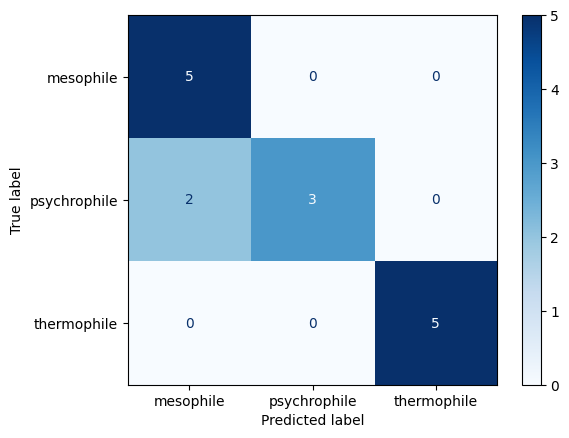

Total Duration: 4.62 minutes


In [4]:
############################################################################################################################################################
# GRANITE4.1
############################################################################################################################################################
from sklearn.metrics import classification_report
from agents import *
import pandas as pd
import json
from tools import *
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('data/example/example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
for acc in accessions:
    result = MESOTHERMOPSYCHRO(acc, "ibm/granite4.1:8b")
    print(f'Accession: {acc}\nThermal Range: {result["thermal_range"]}\n\n')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)

all_df.to_csv('results/granite4.1/result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']
plot=ConfusionMatrix(actual, pred)
plot.plot(cmap='Blues')
plt.savefig('results/granite4.1/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('results/granite4.1/result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual, pred)

with open('results/granite4.1/classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')



In [2]:
format_instructions = parser.get_format_instructions()

NameError: name 'parser' is not defined